In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
BEST_NUM_FEATS = 40
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Train is all games before the 2023 season, holdout is 2023
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2021)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2021) & (MODEL_INPUTS_DF['season'] < 2023)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] == 2023].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.62859	validation_1-auc:0.61280
[1]	validation_0-auc:0.66197	validation_1-auc:0.64133
[2]	validation_0-auc:0.66924	validation_1-auc:0.65000
[3]	validation_0-auc:0.67439	validation_1-auc:0.65311
[4]	validation_0-auc:0.67698	validation_1-auc:0.65110
[0]	validation_0-auc:0.62997	validation_1-auc:0.59419
[0]	validation_0-auc:0.63045	validation_1-auc:0.60743
[5]	validation_0-auc:0.68728	validation_1-auc:0.65164
[1]	validation_0-auc:0.65469	validation_1-auc:0.61932
[2]	validation_0-auc:0.67048	validation_1-auc:0.63391
[1]	validation_0-auc:0.65930	validation_1-auc:0.61370
[0]	validation_0-auc:0.63344	validation_1-auc:0.64533
[3]	validation_0-auc:0.67600	validation_1-auc:0.63781
[6]	validation_0-auc:0.68916	validation_1-auc:0.64729
[1]	validation_0-auc:0.66238	validation_1-auc:0.66002
[4]	validation_0-auc:0.68224	validation_1-auc:0.64108
[2]	validation_0-auc:0.67179	validation_1-auc:0.66206
[2]	validation_0-auc:0.67387	validation_1-auc:0.61817
[7]	validation_0-auc:0.69458

[45]	validation_0-auc:0.70057	validation_1-auc:0.64749
[29]	validation_0-auc:0.73045	validation_1-auc:0.64542
[38]	validation_0-auc:0.69675	validation_1-auc:0.64914
[25]	validation_0-auc:0.72777	validation_1-auc:0.63839
[34]	validation_0-auc:0.70011	validation_1-auc:0.64820
[46]	validation_0-auc:0.70090	validation_1-auc:0.64633
[38]	validation_0-auc:0.73599	validation_1-auc:0.64540
[39]	validation_0-auc:0.69791	validation_1-auc:0.64820
[22]	validation_0-auc:0.72629	validation_1-auc:0.64173
[26]	validation_0-auc:0.72872	validation_1-auc:0.63951
[30]	validation_0-auc:0.73083	validation_1-auc:0.64593
[35]	validation_0-auc:0.70072	validation_1-auc:0.64837
[47]	validation_0-auc:0.70142	validation_1-auc:0.64648
[0]	validation_0-auc:0.64220	validation_1-auc:0.62129
[39]	validation_0-auc:0.73599	validation_1-auc:0.64540
[40]	validation_0-auc:0.69851	validation_1-auc:0.64720
[27]	validation_0-auc:0.72968	validation_1-auc:0.63884
[36]	validation_0-auc:0.70131	validation_1-auc:0.64695
[23]	valida

[29]	validation_0-auc:0.70206	validation_1-auc:0.64875
[1]	validation_0-auc:0.64771	validation_1-auc:0.62358
[3]	validation_0-auc:0.66403	validation_1-auc:0.63822
[1]	validation_0-auc:0.63727	validation_1-auc:0.61748
[6]	validation_0-auc:0.68121	validation_1-auc:0.64286
[9]	validation_0-auc:0.69304	validation_1-auc:0.65309
[28]	validation_0-auc:0.69955	validation_1-auc:0.64901
[39]	validation_0-auc:0.70509	validation_1-auc:0.63833
[0]	validation_0-auc:0.61285	validation_1-auc:0.61458
[30]	validation_0-auc:0.70264	validation_1-auc:0.64727
[4]	validation_0-auc:0.67175	validation_1-auc:0.63606
[2]	validation_0-auc:0.66020	validation_1-auc:0.63806
[2]	validation_0-auc:0.65152	validation_1-auc:0.62516
[37]	validation_0-auc:0.72411	validation_1-auc:0.63777
[29]	validation_0-auc:0.70065	validation_1-auc:0.64922
[7]	validation_0-auc:0.68474	validation_1-auc:0.63925
[27]	validation_0-auc:0.70343	validation_1-auc:0.64551
[45]	validation_0-auc:0.70724	validation_1-auc:0.64246
[1]	validation_0-auc

[29]	validation_0-auc:0.62790	validation_1-auc:0.62880
[27]	validation_0-auc:0.61329	validation_1-auc:0.60883
[19]	validation_0-auc:0.70027	validation_1-auc:0.64774
[32]	validation_0-auc:0.62534	validation_1-auc:0.61820
[2]	validation_0-auc:0.61902	validation_1-auc:0.63252
[29]	validation_0-auc:0.62566	validation_1-auc:0.62290
[6]	validation_0-auc:0.62518	validation_1-auc:0.62484
[30]	validation_0-auc:0.62790	validation_1-auc:0.62880
[28]	validation_0-auc:0.61329	validation_1-auc:0.60883
[20]	validation_0-auc:0.70147	validation_1-auc:0.64579
[33]	validation_0-auc:0.62534	validation_1-auc:0.61820
[30]	validation_0-auc:0.62566	validation_1-auc:0.62290
[7]	validation_0-auc:0.62518	validation_1-auc:0.62484
[31]	validation_0-auc:0.62790	validation_1-auc:0.62880
[3]	validation_0-auc:0.63099	validation_1-auc:0.63676
[29]	validation_0-auc:0.61329	validation_1-auc:0.60883
[21]	validation_0-auc:0.70250	validation_1-auc:0.64634
[8]	validation_0-auc:0.64141	validation_1-auc:0.63138
[32]	validation

[39]	validation_0-auc:0.65415	validation_1-auc:0.63708
[23]	validation_0-auc:0.68438	validation_1-auc:0.65196
[27]	validation_0-auc:0.70663	validation_1-auc:0.64364
[1]	validation_0-auc:0.64056	validation_1-auc:0.63697
[19]	validation_0-auc:0.68171	validation_1-auc:0.65056
[24]	validation_0-auc:0.68433	validation_1-auc:0.65227
[2]	validation_0-auc:0.65133	validation_1-auc:0.64761
[28]	validation_0-auc:0.70711	validation_1-auc:0.64367
[20]	validation_0-auc:0.68322	validation_1-auc:0.64994
[25]	validation_0-auc:0.68547	validation_1-auc:0.65193
[29]	validation_0-auc:0.70751	validation_1-auc:0.64311
[3]	validation_0-auc:0.65165	validation_1-auc:0.65019
[26]	validation_0-auc:0.68601	validation_1-auc:0.65236
[21]	validation_0-auc:0.68293	validation_1-auc:0.65118
[27]	validation_0-auc:0.68689	validation_1-auc:0.65250
[22]	validation_0-auc:0.68301	validation_1-auc:0.65338
[23]	validation_0-auc:0.68412	validation_1-auc:0.65300
[4]	validation_0-auc:0.65633	validation_1-auc:0.65192
[0]	validation

...

[36]	validation_0-auc:0.74147	validation_1-auc:0.63364


[37]	validation_0-auc:0.74247	validation_1-auc:0.63282


[38]	validation_0-auc:0.74247	validation_1-auc:0.63282


[39]	validation_0-auc:0.74269	validation_1-auc:0.63356




Best parameters found:  {'subsample': 0.9, 'n_estimators': 40, 'min_child_weight': 50, 'max_depth': 3, 'learning_rate': 0.2, 'importance_type': 'total_gain', 'gamma': 5, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  0.6772326408171596


Best Selected Features:  ['def_opp_rushing_yards_cumulative_average', 'opp_def_cumulative_avg_points_allowed', 'off_target_passing_epa_cumulative_average', 'off_opp_dakota_cumulative_average', 'off_opp_passing_epa_cumulative_average', 'off_target_passing_epa', 'off_opp_rushing_first_downs_cumulative_average_change', 'is_home_target', 'target_off_cumulative_avg_score_rank', 'target_def_cumulative_avg_points_allowed', 'off_opp_rushing_first_downs_cumulative_average', 'off_target_rushing_first_downs_cumulative_average', 'off_target_dakota_cumulative_average', 'off_target_passing_yards', 'def_target_sacks_cumulative_average_change', 'off_opp_sacks_cumulative_average_change', 'def_opp_rushing_first_downs_cumulative_average', 'def_

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.17465634, 0.20175943, 0.18646908, 0.17962799, 0.20138078,
        0.07230158, 0.10677142, 0.10245552, 0.16513538, 0.12747984,
        0.08083439, 0.0741992 , 0.16309738, 0.13406525, 0.12989192,
        0.11222138, 0.09681911, 0.11111908, 0.10401812, 0.07696261,
        0.07397518, 0.10314145, 0.10991068, 0.14747887, 0.14868793,
        0.20164571, 0.1025178 , 0.10557585, 0.14447231, 0.14790626,
        0.13164582, 0.21391845, 0.1099381 , 0.17607026, 0.07717547,
        0.0772902 , 0.10556383, 0.13538222, 0.08093476, 0.11045241,
        0.16942964, 0.16654415, 0.09191289, 0.09732413, 0.15711002,
        0.0744113 , 0.06821785, 0.101578  , 0.13641763, 0.12816916,
        0.12846704, 0.06309676, 0.21687164, 0.07496877, 0.14832053,
        0.10674438, 0.20169568, 0.0851706 , 0.185428  , 0.0998251 ,
        0.13430767, 0.12624779, 0.06798267, 0.07107735, 0.10693741,
        0.1270618 , 0.09745393, 0.0966928 , 0.14095507, 0.20058026,
        0.11193075, 0.10770483,

<Axes: >

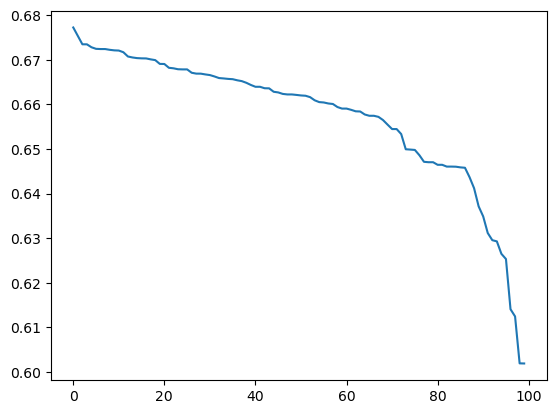

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.186469,0.015695,0.002633,0.000061,0.9,40,50,3,0.2,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.684675,0.674389,0.657982,0.673161,0.695956,0.677233,0.012659,1
1,0.201646,0.018297,0.002400,0.000111,0.9,50,20,3,0.03,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 50, 'min_ch...",0.669287,0.672906,0.664632,0.674520,0.695368,0.675343,0.010574,2
2,0.127062,0.009573,0.002579,0.000771,0.7,30,50,2,0.1,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 30, 'min_ch...",0.673407,0.671281,0.660039,0.665811,0.696784,0.673465,0.012549,3
3,0.112221,0.005165,0.002360,0.000241,0.5,20,20,3,0.15,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 20, 'min_ch...",0.649542,0.670718,0.661815,0.688546,0.696636,0.673452,0.017204,4
4,0.104018,0.012918,0.002420,0.000348,0.9,20,100,2,0.15,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 20, 'min_ch...",0.672985,0.676443,0.664279,0.659782,0.690490,0.672796,0.010661,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.5992647058823529

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2023_01_ARI_WAS,1,ARI,WAS,0,0.420986
1,2023_01_ARI_WAS,1,WAS,ARI,1,0.521424
2,2023_01_BUF_NYJ,1,NYJ,BUF,1,0.429480
3,2023_01_BUF_NYJ,1,BUF,NYJ,0,0.603419
4,2023_01_CAR_ATL,1,ATL,CAR,1,0.580099
...,...,...,...,...,...,...
539,2023_18_PIT_BAL,18,BAL,PIT,0,0.704217
540,2023_18_SEA_ARI,18,ARI,SEA,0,0.463833
541,2023_18_SEA_ARI,18,SEA,ARI,1,0.565135
542,2023_18_TB_CAR,18,CAR,TB,0,0.352178


week
1     0.625000
2     0.423828
3     0.558594
4     0.964844
5     0.418367
6     0.666667
7     0.372781
8     0.703125
9     0.775510
10    0.602041
11    0.887755
12    0.593750
13    0.698225
14    0.488889
15    0.843750
16    0.615234
17    0.785156
18    0.550781
dtype: float64

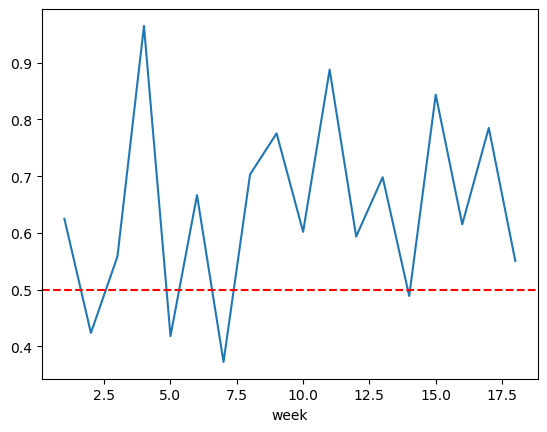

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.666667
2     0.444444
3     0.703125
4     0.857143
5     0.622222
6     0.767857
7     0.450000
8     0.395833
9     0.666667
10    0.645833
11    0.757576
12    0.400000
13    0.333333
14    0.592593
15    0.708333
16    0.579365
17    0.709091
18    0.266667
dtype: float64

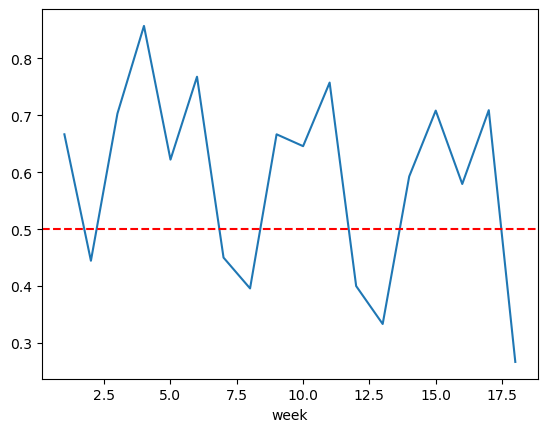

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores